In [11]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tensorflow.keras import layers, models

# Load the PneumoniaMNIST dataset from tfds
(train_ds, val_ds, test_ds), ds_info = tfds.load(
    'pneumonia_mnist',
    split=['train', 'val', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

print("Dataset info:", ds_info)

Dataset info: tfds.core.DatasetInfo(
    name='pneumonia_mnist',
    full_name='pneumonia_mnist/1.0.0',
    description="""
    # MedMNIST Pneumonia Dataset
    
    The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray
    images. The task is binary-class classification of pneumonia against normal. The
    source training set is split with a ratio of 9:1 into training and validation
    set, and use its source validation set as the test set. The source images are
    gray-scale, and their sizes are (384–2,916) × (127–2,713). The images are
    center-cropped with a window size of length of the short edge and resized into 1
    × 28 × 28.
    """,
    homepage='https://medmnist.com//',
    data_dir='/home/miguel/tensorflow_datasets/pneumonia_mnist/1.0.0',
    file_format=tfrecord,
    download_size=3.98 MiB,
    dataset_size=3.66 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=i

In [12]:
# Function to preprocess the dataset
def preprocess_data(image, label):
    """Preprocess images - normalize and expand to 3 channels"""
    image = tf.cast(image, tf.float32) / 255.0
    return image, tf.cast(label, tf.int32)

# Apply preprocessing to all datasets
train_ds = train_ds.map(preprocess_data)
val_ds = val_ds.map(preprocess_data)
test_ds = test_ds.map(preprocess_data)

# Create batched datasets for training
BATCH_SIZE = 32
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [13]:
# Extract samples for visualization and dataset analysis
train_samples = []
train_labels_list = []
for images, labels in train_ds.unbatch().take(4708):  # Take all training samples
    train_samples.append(images.numpy())
    train_labels_list.append(labels.numpy())
    
train_samples = np.array(train_samples)
train_labels_list = np.array(train_labels_list)

test_samples = []
test_labels_list = []
for images, labels in test_ds.unbatch().take(624):  # Take all test samples
    test_samples.append(images.numpy())
    test_labels_list.append(labels.numpy())
    
test_samples = np.array(test_samples)
test_labels_list = np.array(test_labels_list)

val_samples = []
val_labels_list = []
for images, labels in val_ds.unbatch().take(524):  # Take all validation samples
    val_samples.append(images.numpy())
    val_labels_list.append(labels.numpy())
    
val_samples = np.array(val_samples)
val_labels_list = np.array(val_labels_list)

# Print the shapes
print("Train - images:", train_samples.shape, " labels:", train_labels_list.shape)
print("Test  - images:", test_samples.shape, " labels:", test_labels_list.shape) 
print("Val   - images:", val_samples.shape, " labels:", val_labels_list.shape)

2025-03-14 10:46:52.408171: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Train - images: (4708, 28, 28, 1)  labels: (4708,)
Test  - images: (624, 28, 28, 1)  labels: (624,)
Val   - images: (524, 28, 28, 1)  labels: (524,)


In [14]:
# Check the unique labels in all sets
unique_train, counts_train = np.unique(train_labels_list, return_counts=True)
unique_test, counts_test = np.unique(test_labels_list, return_counts=True)
unique_val, counts_val = np.unique(val_labels_list, return_counts=True)

print("\nDistribution of labels in each set:")
print("Training set   - Normal: {}, Pneumonia: {}".format(counts_train[0], counts_train[1]))
print("Testing set    - Normal: {}, Pneumonia: {}".format(counts_test[0], counts_test[1]))
print("Validation set - Normal: {}, Pneumonia: {}".format(counts_val[0], counts_val[1]))


Distribution of labels in each set:
Training set   - Normal: 1214, Pneumonia: 3494
Testing set    - Normal: 234, Pneumonia: 390
Validation set - Normal: 135, Pneumonia: 389


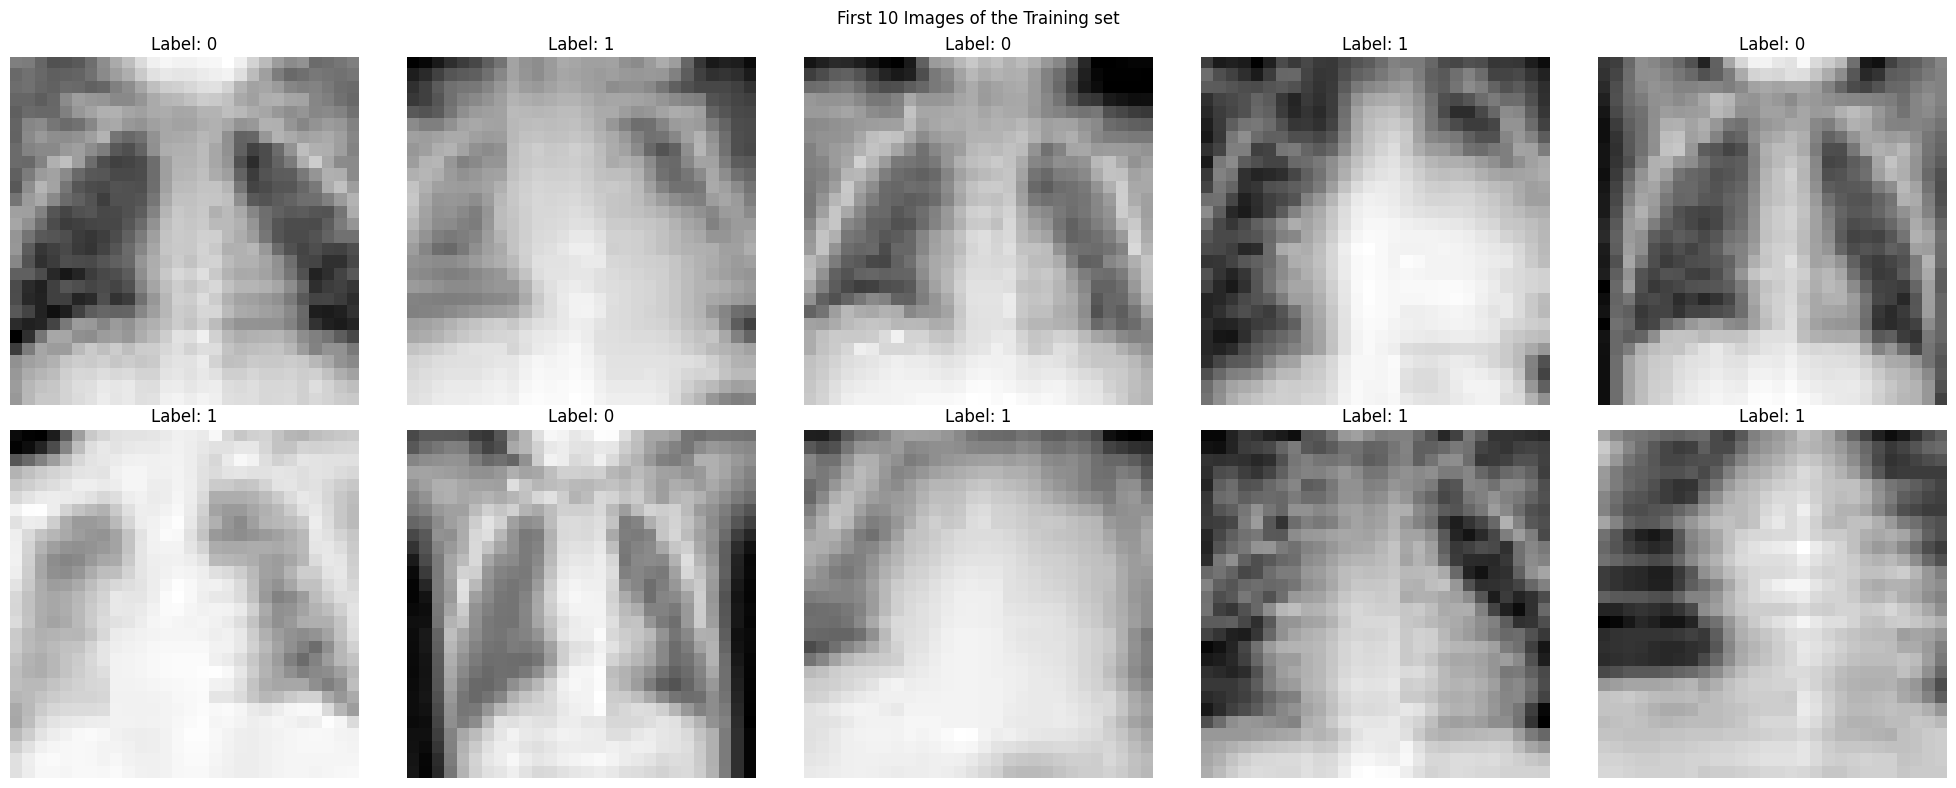

In [15]:
# Plot 10 images in a 2x5 grid from the training set
num_images = 10
fig, axs = plt.subplots(2, 5, figsize=(20, 8))
for i in range(2):
    for j in range(5):
        idx = i * 5 + j
        axs[i,j].imshow(train_samples[idx], cmap='gray')
        axs[i,j].set_title(f"Label: {train_labels_list[idx]}")
        axs[i,j].axis('off')
plt.suptitle(f"First {num_images} Images of the Training set")
plt.tight_layout()
plt.show()